# Fairbairn Accessors ($p, q, h$) vs $R/R_g$

Plots the local power-law exponents $p$ ($\Sigma \propto r^{-p}$), $q$ ($T \propto r^{-q}$), and aspect ratio $h = H/r$ across three Sirko-Goodman hybrid disk models, with Fairbairn grid coverage and physically-derived zone boundaries.

## Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import multiprocessing as mp
from astropy import units as u
from astropy.constants import sigma_T, m_p, G, c, k_B, sigma_sb
from disktab import AGNDisk

sns.set_theme(style="whitegrid", context="notebook")

## Disk model generation

In [2]:
M = 1e8 * u.Msun
epsilon = 0.1
kappa = sigma_T / m_p
L_Edd = 4 * np.pi * G * M * c / kappa
Mdot_Edd = (L_Edd / (epsilon * c**2)).to(u.kg / u.s)
rvals = np.logspace(1, 9, 2000)

print(f"Mdot_Edd = {Mdot_Edd:.3e}")

Mdot_Edd = 1.399e+23 kg / s


In [3]:
def _generate_disk(args):
    """Worker function for parallel disk generation. Returns only the DataFrame."""
    M, alpha, Mdot, rvals = args
    disk = AGNDisk()
    disk.M = M
    disk.alpha = alpha
    disk.Mdot = Mdot
    return disk.spacehub_pretab(rvals=rvals)

configs = [
    (M, 0.1, 0.01 * Mdot_Edd, rvals),
    (M, 0.1, 0.25 * Mdot_Edd, rvals),
    (M, 0.1, 1.0 * Mdot_Edd, rvals),
]

with mp.Pool(len(configs)) as pool:
    df1, df2, df3 = pool.map(_generate_disk, configs)

# Reconstruct reference disk (used for zone boundaries in later cells)
disk1 = AGNDisk()
disk1.M = M
disk1.alpha = 0.1
disk1.Mdot = 0.01 * Mdot_Edd
disk1.generate(rvals=rvals)

df3.tail(3)

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1115: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [643, 843) around index 743 (R/Rg ≈ 9407.8) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  self.generate(rvals=rvals)
/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1115: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [551, 751) around index 651 (R/Rg ≈ 4030.0) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  self.generate(rvals=rvals)
/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1115: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [542, 742) around index 642 (R/Rg ≈ 3709.2) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  self.generate(rvals=rvals)
/tmp/ipykernel_2980/35687218

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,grad_T,grad_Sigma,grad_P,zone,grad_P_raw,grad_Sigma_raw
1997,9.690380e+08,9.817389e+08,2.526708,1.748979e-20,1.950331e-20,1.055995,3.185472e+09,3.363842e+08,1.114265e-10,1.0,0.749987,1.499987,2.999974,Self-Reg,2.999974,1.499987
1998,9.780089e+08,9.908274e+08,2.509306,1.701291e-20,1.897153e-20,1.055995,3.229809e+09,3.410663e+08,1.098969e-10,1.0,0.749987,1.499987,2.999974,Self-Reg,2.999974,1.499987
1999,9.870629e+08,1.000000e+09,2.492024,1.654903e-20,1.845426e-20,1.055995,3.274763e+09,3.458134e+08,1.083883e-10,1.0,0.749987,1.499987,2.999974,Self-Reg,2.999974,1.499987


## Build long-form DataFrame

In [4]:
models = {
    r"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=0.01": df1,
    r"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=0.25": df2,
    r"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=1.0": df3,
}

frames = []
for label, df in models.items():
    tmp = pd.DataFrame({
        "R/Rg": np.tile(df["R/Rg"].values, 3),
        "value": np.concatenate([df["grad_Sigma"].values, df["grad_T"].values, (df["H"] / df["R"]).values]),
        "parameter": np.repeat(["p (surface density)", "q (temperature)", "h (aspect ratio)"], len(df)),
        "model": label,
    })
    frames.append(tmp)

plot_df = pd.concat(frames, ignore_index=True)
plot_df.head()

,R/Rg,value,parameter,model
0,10.000000,0.137925,p (surface density),"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=0.01"
1,10.092575,0.123742,p (surface density),"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=0.01"
2,10.186008,0.095830,p (surface density),"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=0.01"
3,10.280305,0.068810,p (surface density),"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=0.01"
4,10.375475,0.042643,p (surface density),"$\alpha$=0.1, $\dot{M}/\dot{M}_{\rm Edd}$=0.01"


## Zone boundaries

**Radiation/gas boundary**: where $P_{\rm rad} = P_{\rm gas}$, computed from the reference model's SI-unit internal state.  
**Q=1 boundary**: from `disk.selfreg_threshold`.

In [5]:
# Reference model for zone shading: alpha=0.1, Mdot/Medd=0.5
ref_disk = disk1
ref_model = ref_disk.model  # SI units

# P_rad / P_gas ratio
mu = ref_disk.mu
P_gas = ref_model["rho"] * k_B.value * ref_model["Tc"] / (mu * m_p.value)
P_rad = 4 * sigma_sb.value * ref_model["Tc"]**4 / (3 * c.value)
ratio = P_rad / P_gas

# Interpolate where P_rad/P_gas = 1 (radiation → gas transition)
from scipy.interpolate import interp1d
log_ratio = np.log10(ratio.values)
r_rg = ref_model["R/Rg"].values
# ratio decreases outward; find crossing
cross_idx = np.where(np.diff(np.sign(log_ratio)))[0]
if len(cross_idx) > 0:
    i = cross_idx[0]
    # Linear interpolation in log-log
    frac = -log_ratio[i] / (log_ratio[i+1] - log_ratio[i])
    R_rad_gas = 10**(np.log10(r_rg[i]) + frac * (np.log10(r_rg[i+1]) - np.log10(r_rg[i])))
else:
    R_rad_gas = r_rg[0]  # fallback

# Q=1 boundary
R_Q1 = (ref_disk.selfreg_threshold / ref_disk.gRad).si.value

print(f"Radiation/Gas boundary: R/Rg = {R_rad_gas:.1f}")
print(f"Q=1 boundary:          R/Rg = {R_Q1:.1f}")

Radiation/Gas boundary: R/Rg = 127.5
Q=1 boundary:          R/Rg = 9321.5


## Fairbairn grid bounds

In [6]:
with open(os.path.join("..", "FairbairnData", "eccentric", "parameters.out")) as f:
    q_grid = np.array(f.readline().split(), dtype=float)
    p_grid = np.array(f.readline().split(), dtype=float)
    h_grid = np.array(f.readline().split(), dtype=float)

fairbairn_bounds = {
    "p (surface density)": (p_grid.min(), p_grid.max()),
    "q (temperature)":     (q_grid.min(), q_grid.max()),
    "h (aspect ratio)":    (h_grid.min(), h_grid.max()),
}
fairbairn_bounds

{'p (surface density)': (np.float64(0.0), np.float64(1.5)),
 'q (temperature)': (np.float64(0.0), np.float64(0.75)),
 'h (aspect ratio)': (np.float64(0.06), np.float64(0.1))}

## Plot

/tmp/ipykernel_2980/721507573.py:35: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(-3,0)


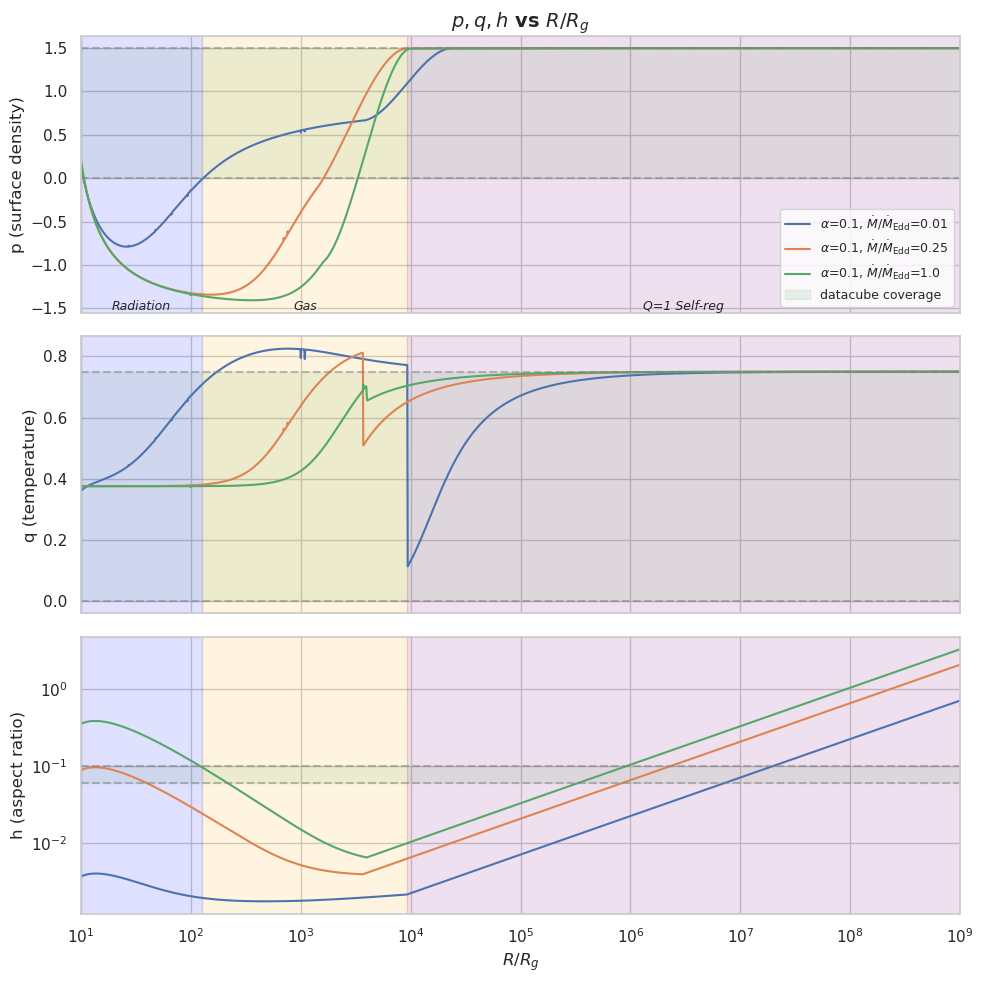

In [7]:
param_order = ["p (surface density)", "q (temperature)", "h (aspect ratio)"]
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for i, (ax, param) in enumerate(zip(axes, param_order)):
    sub = plot_df[plot_df["parameter"] == param]
    sns.lineplot(data=sub, x="R/Rg", y="value", hue="model", ax=ax, linewidth=1.5)

    # Fairbairn coverage band
    lo, hi = fairbairn_bounds[param]
    ax.axhline(lo, color="gray", ls="--", alpha=0.5)
    ax.axhline(hi, color="gray", ls="--", alpha=0.5)
    ax.fill_between(ax.get_xlim(), lo, hi, color="green", alpha=0.08, label="datacube coverage")

    # Zone shading
    ax.axvspan(rvals.min(), R_rad_gas, alpha=0.12, color="blue")
    ax.axvspan(R_rad_gas, R_Q1, alpha=0.12, color="orange")
    ax.axvspan(R_Q1, rvals.max(), alpha=0.12, color="purple")

    ax.set_xscale("log")
    ax.set_ylabel(param, fontsize=12)
    ax.set_xlim(10,10**9)

    if i > 0:
        ax.get_legend().remove()

# Zone labels
for rx, lbl in [(np.sqrt(rvals.min() * R_rad_gas), "Radiation"),
                (np.sqrt(R_rad_gas * R_Q1), "Gas"),
                (np.sqrt(R_Q1 * rvals.max()), "Q=1 Self-reg")]:
    axes[0].text(rx, axes[0].get_ylim()[0], lbl, ha="center", va="bottom", fontsize=9, fontstyle="italic")

axes[0].set_title(r"$p, q, h$ vs $R/R_g$", fontsize=14, fontweight="bold")
axes[-1].set_xlabel(r"$R/R_g$", fontsize=12)
axes[2].set_yscale("log")
axes[2].set_ylim(-3,0)
axes[0].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2980/2025674397.py:82: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(-3, 0)


Saved to fairbairn_accessors.pdf


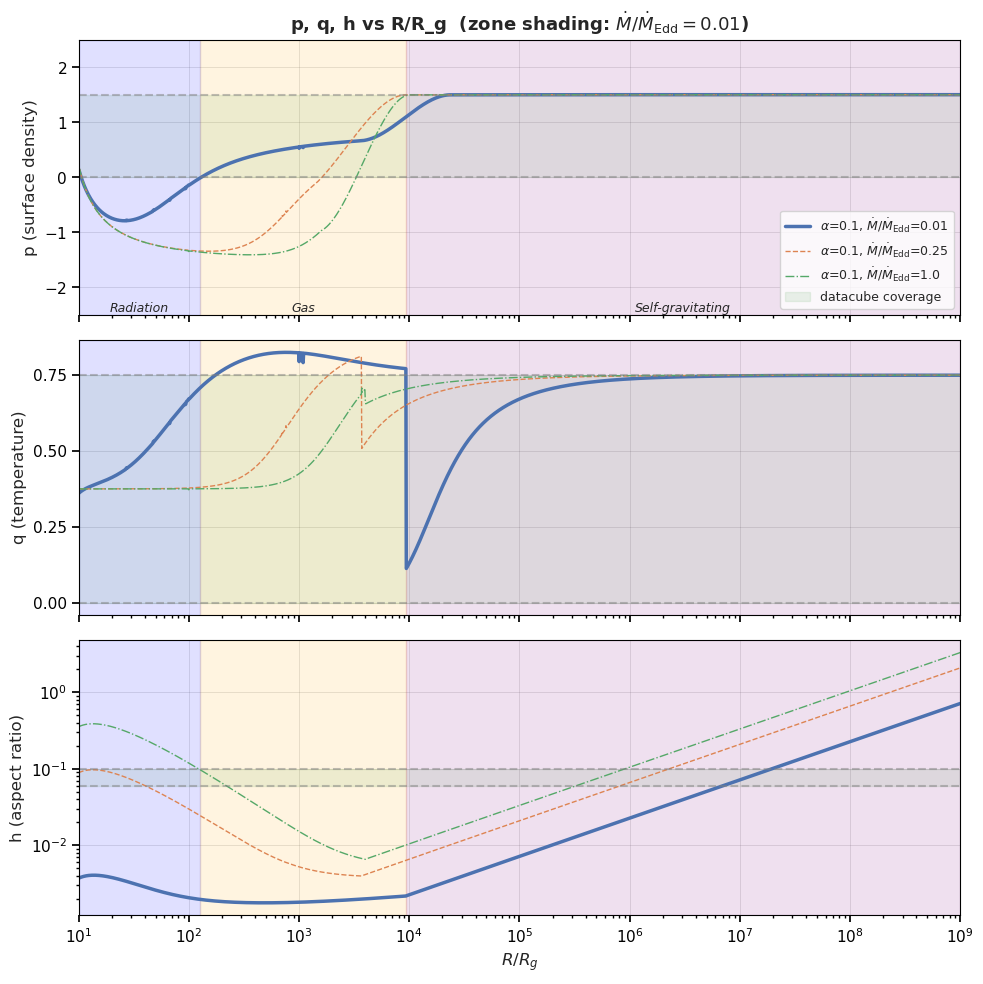

In [8]:
from matplotlib import ticker as _ticker

_param_order = ["p (surface density)", "q (temperature)", "h (aspect ratio)"]
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Define model keys and per-model line styles
# 1% Eddington is the reference model (zone shading follows it) → bold solid
# Others are secondary → thinner, dashed/dash-dot
_model_keys = list(models.keys())  # 0.01, 0.25, 1.0 in order
_prop_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_line_cfg = {
    _model_keys[0]: dict(linewidth=2.5, linestyle="-",  color=_prop_colors[0]),
    _model_keys[1]: dict(linewidth=1.0, linestyle="--", color=_prop_colors[1]),
    _model_keys[2]: dict(linewidth=1.0, linestyle="-.", color=_prop_colors[2]),
}

for i, (ax, param) in enumerate(zip(axes, _param_order)):
    sub = plot_df[plot_df["parameter"] == param]

    # Plot each model separately so we can control linestyle per model
    for mdl_key in _model_keys:
        mdl_sub = sub[sub["model"] == mdl_key]
        ax.plot(mdl_sub["R/Rg"].values, mdl_sub["value"].values,
                label=mdl_key if i == 0 else None,
                **_line_cfg[mdl_key])

    # Fairbairn coverage band
    lo, hi = fairbairn_bounds[param]
    ax.axhline(lo, color="gray", ls="--", alpha=0.5)
    ax.axhline(hi, color="gray", ls="--", alpha=0.5)
    ax.fill_between(ax.get_xlim(), lo, hi, color="green", alpha=0.08,
                    label="datacube coverage" if i == 0 else None)

    # Zone shading
    ax.axvspan(rvals.min(), R_rad_gas, alpha=0.12, color="blue")
    ax.axvspan(R_rad_gas, R_Q1, alpha=0.12, color="orange")
    ax.axvspan(R_Q1, rvals.max(), alpha=0.12, color="purple")

    ax.set_xscale("log")
    ax.set_ylabel(param, fontsize=12)
    ax.set_xlim(10, 10**9)

    # ── Override seaborn whitegrid: match accessDataCube aesthetic ─────────
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(axis="x", which="both", bottom=True, color="black", labelcolor="black",
                   direction="out")
    ax.tick_params(axis="y", which="both", left=True, color="black", labelcolor="black",
                   direction="out")
    ax.tick_params(which="major", length=5)
    ax.tick_params(which="minor", length=2.5)

    ax.grid(True, which="major", color="gray", alpha=0.3, linewidth=0.5)
    ax.grid(False, which="minor")
    ax.set_axisbelow(True)

    # Y-axis ticks
    if param == "p (surface density)":
        ax.set_yticks([-2, -1, 0, 1, 2])
        ax.set_yticklabels([r"$-2$", r"$-1$", r"$0$", r"$1$", r"$2$"])
        ax.set_ylim(-2.5, 2.5)
    elif param != "h (aspect ratio)":
        ax.yaxis.set_major_locator(_ticker.MaxNLocator(nbins=4, prune="both"))

    ax.xaxis.set_major_locator(_ticker.LogLocator(base=10.0, numticks=12))
    ax.xaxis.set_minor_locator(_ticker.LogLocator(base=10.0, subs=np.arange(2, 10)))
    ax.xaxis.set_minor_formatter(_ticker.NullFormatter())

# Zone labels
for rx, lbl in [(np.sqrt(rvals.min() * R_rad_gas), "Radiation"),
                (np.sqrt(R_rad_gas * R_Q1), "Gas"),
                (np.sqrt(R_Q1 * rvals.max()), "Self-gravitating")]:
    axes[0].text(rx, axes[0].get_ylim()[0], lbl, ha="center", va="bottom", fontsize=9, fontstyle="italic")

axes[0].set_title(r"p, q, h vs R/R_g  (zone shading: $\dot{M}/\dot{M}_{\rm Edd}=0.01$)",
                  fontsize=13, fontweight="bold")
axes[-1].set_xlabel(r"$R/R_g$", fontsize=12)
axes[2].set_yscale("log")
axes[2].set_ylim(-3, 0)
axes[0].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.savefig("fairbairn_accessors.pdf", dpi=300, bbox_inches="tight")
print("Saved to fairbairn_accessors.pdf")